In [80]:
import pandas as pd
import numpy as np

sales = pd.read_csv("../data/processed/sales.csv")
web_traffic = pd.read_csv("../data/processed/web_traffic.csv")
products = pd.read_csv("../data/processed/products.csv")
orders = pd.read_csv("../data/processed/orders.csv")
promotions = pd.read_csv("../data/processed/promotions.csv")
inventory = pd.read_csv("../data/processed/inventory.csv")
order_items = pd.read_csv("../data/processed/order_items.csv")
returns = pd.read_csv("../data/processed/returns.csv")
reviews = pd.read_csv("../data/processed/reviews.csv")
sample_submission = pd.read_csv("../data/processed/sample_submission.csv")
shipments = pd.read_csv("../data/processed/shipments.csv")
np.random.seed(0)

In [81]:
def percent_missing(file_name):
    total = np.prod(file_name.shape)
    missing = file_name.isnull().sum()
    total_missing = missing.sum()
    per_missing = (total_missing/total) * 100
    return per_missing

In [82]:
print(f"Percent Missing sales: {percent_missing(sales)}")
print(f"Percent Missing web_traffic: {percent_missing(web_traffic)}")
print(f"Percent Missing products: {percent_missing(products)}")
print(f"Percent Missing orders: {percent_missing(orders)}")
print(f"Percent Missing promotions: {percent_missing(promotions)}")
print(f"Percent Missing inventory: {percent_missing(inventory)}")
print(f"Percent Missing order_items: {percent_missing(order_items)}")


Percent Missing sales: 0.0
Percent Missing web_traffic: 0.0
Percent Missing products: 0.0
Percent Missing orders: 0.0
Percent Missing promotions: 0.0
Percent Missing inventory: 0.0
Percent Missing order_items: 0.0


In [83]:
order_items['promo_id'] = order_items['promo_id'].fillna('NO_PROMO')
order_items['promo_id_2'] = order_items['promo_id_2'].fillna('NO_PROMO')
order_items.to_csv('../data/processed/order_items.csv', index=False)
print("Saved: ../data/processed/order_items.csv")
order_items.head()

Saved: ../data/processed/order_items.csv


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,NO_PROMO,NO_PROMO
1,2,609,7,10166.25,0.0,NO_PROMO,NO_PROMO
2,3,396,3,11220.33,0.0,NO_PROMO,NO_PROMO
3,4,635,5,10639.25,0.0,NO_PROMO,NO_PROMO
4,6,1935,1,1597.84,0.0,NO_PROMO,NO_PROMO


In [84]:
promotions.head()

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,All,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,All,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,All,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,All,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000


In [85]:
promotions['applicable_category'] = promotions['applicable_category'].fillna('All')
promotions.to_csv('../data/processed/promotions.csv', index=False)
print("Saved: ../data/processed/promotions.csv")

Saved: ../data/processed/promotions.csv


In [86]:
promotions.head()

,promo_id,promo_name,promo_type,discount_value,start_date,end_date,applicable_category,promo_channel,stackable_flag,min_order_value
0,PROMO-0001,Spring Sale 2013,percentage,12.0,2013-03-18,2013-04-17,All,email,1,0
1,PROMO-0002,Mid-Year Sale 2013,percentage,18.0,2013-06-23,2013-07-22,All,online,0,0
2,PROMO-0003,Fall Launch 2013,percentage,10.0,2013-08-30,2013-10-02,All,email,0,0
3,PROMO-0004,Year-End Sale 2013,percentage,20.0,2013-11-18,2014-01-02,All,all_channels,0,50000
4,PROMO-0005,Urban Blowout 2013,fixed,50.0,2013-07-30,2013-09-02,Streetwear,online,0,150000


In [87]:
print(f"Percent Missing promotions: {percent_missing(promotions)}")

Percent Missing promotions: 0.0


In [88]:
print(f"Date type sales: {sales['Date'].dtype}")
print(f"Date type web_traffic: {web_traffic['date'].dtype}")
print(f"Date type orders: {orders['order_date'].dtype}")
print(f"Date type promotions: {promotions['start_date'].dtype}, {promotions['end_date'].dtype}")

Date type sales: str
Date type web_traffic: str
Date type orders: str
Date type promotions: str, str


In [89]:
sales['Date'] = pd.to_datetime(sales['Date'], format="%Y-%m-%d")
web_traffic['date'] = pd.to_datetime(web_traffic['date'], format="%Y-%m-%d")
orders['order_date'] = pd.to_datetime(orders['order_date'], format="%Y-%m-%d")
promotions['start_date'] = pd.to_datetime(promotions['start_date'], format="%Y-%m-%d")
promotions['end_date'] = pd.to_datetime(promotions['end_date'], format="%Y-%m-%d")
inventory['snapshot_date'] = pd.to_datetime(inventory['snapshot_date'], format="%Y-%m-%d")
returns['return_date'] = pd.to_datetime(returns['return_date'], format="%Y-%m-%d")
reviews['review_date'] = pd.to_datetime(reviews['review_date'], format="%Y-%m-%d")
shipments['ship_date'] = pd.to_datetime(shipments['ship_date'], format="%Y-%m-%d")
shipments['delivery_date'] = pd.to_datetime(shipments['delivery_date'], format="%Y-%m-%d")
sample_submission['Date'] = pd.to_datetime(sample_submission['Date'], format="%Y-%m-%d")

In [90]:
print(f"Date type sales: {sales['Date'].dtype}")
print(f"Date type web_traffic: {web_traffic['date'].dtype}")
print(f"Date type orders: {orders['order_date'].dtype}")
print(f"Date type promotions: {promotions['start_date'].dtype}, {promotions['end_date'].dtype}")
print(f"Date type inventory: {inventory['snapshot_date'].dtype}")
print(f"Date type returns: {returns['return_date'].dtype}")
print(f"Date type reviews: {reviews['review_date'].dtype}")
print(f"Date type shipments (shipping): {shipments['ship_date'].dtype}")
print(f"Date type sample_submission: {sample_submission['Date'].dtype}")
print(f"Date type shipments (delivery): {shipments['delivery_date'].dtype}")

Date type sales: datetime64[us]
Date type web_traffic: datetime64[us]
Date type orders: datetime64[us]
Date type promotions: datetime64[us], datetime64[us]
Date type inventory: datetime64[us]
Date type returns: datetime64[us]
Date type reviews: datetime64[us]
Date type shipments (shipping): datetime64[us]
Date type sample_submission: datetime64[us]
Date type shipments (delivery): datetime64[us]


In [91]:
dfs = {
    "Sales": sales,
    "Web Traffic": web_traffic,
    "Products": products,
    "Orders": orders,
    "Promotions": promotions,
    "Inventory": inventory
}

def check_quality(name, df):
    duplicates = df.duplicated().sum()
    print(f"{name}: {duplicates} dòng trùng lặp")

for name, df in dfs.items():
    check_quality(name, df)

Sales: 0 dòng trùng lặp
Web Traffic: 0 dòng trùng lặp
Products: 0 dòng trùng lặp
Orders: 0 dòng trùng lặp
Promotions: 0 dòng trùng lặp
Inventory: 0 dòng trùng lặp


In [92]:
# Kiểm tra Products: Giá vốn < Giá bán 
invalid_products = products[products['cogs'] >= products['price']]
print(f"cogs < price: {len(invalid_products)}")

# Kiểm tra Promotions: Ngày bắt đầu < Ngày kết thúc 
invalid_promos = promotions[promotions['start_date'] >= promotions['end_date']]
print(f"start_date < end_date: {len(invalid_promos)}")

# Kiểm tra Sales: Doanh thu hoặc COGS có bị âm không 
invalid_sales = sales[(sales['Revenue'] < 0) | (sales['COGS'] < 0)]
print(f"Revenue, COGS < 0: {len(invalid_sales)}")

# Kiểm tra Web Traffic: Các tỷ lệ (rate) phải nằm trong khoảng [0, 1] 
invalid_traffic = web_traffic[(web_traffic['bounce_rate'] < 0) | (web_traffic['bounce_rate'] > 1)]
print(f"rate < 0, rate > 1: {len(invalid_traffic)}")

cogs < price: 0
start_date < end_date: 0
Revenue, COGS < 0: 0
rate < 0, rate > 1: 0


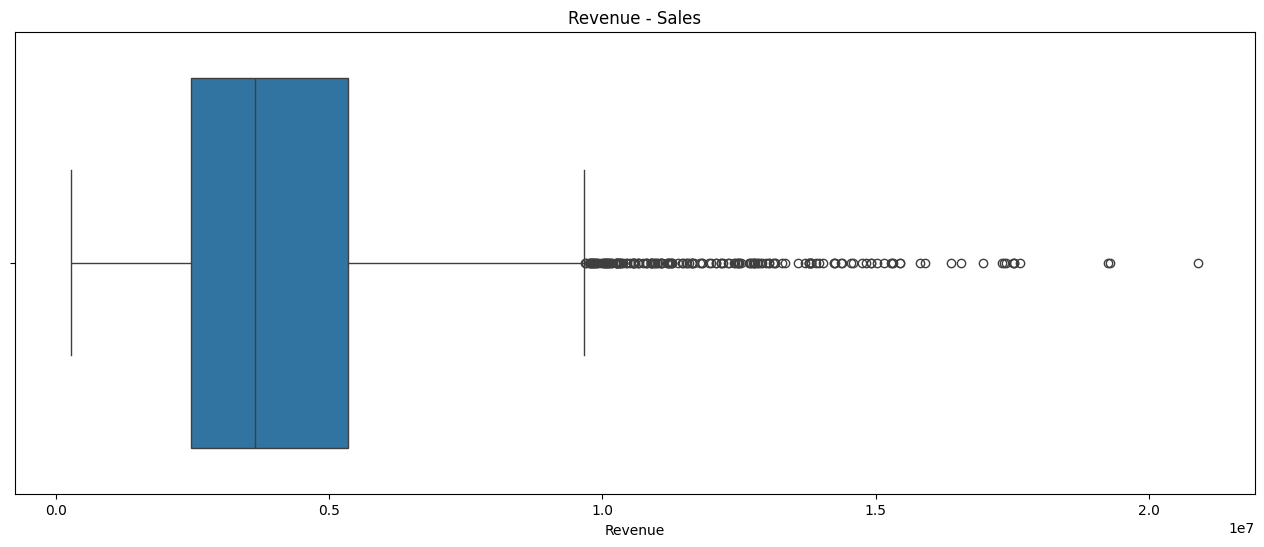

In [93]:
import seaborn as sns
import matplotlib.pyplot as plt

# Revenue trong sales.csv 
plt.figure(figsize=(16,6)) 
sns.boxplot(x=sales['Revenue'])
plt.title("Revenue - Sales")
plt.show()

In [94]:
Q1 = sales['Revenue'].quantile(0.25)
Q3 = sales['Revenue'].quantile(0.75)
IQR = Q3 - Q1
upper_limit = Q3 + 1.5 * IQR

high_revenue_days = sales[sales['Revenue'] > upper_limit]
print(high_revenue_days.sort_values(by='Revenue', ascending=False).head(10))

           Date      Revenue         COGS  is_holiday  log_Revenue   log_COGS
2156 2018-05-30  20905271.35  16535857.67           1    16.855512  16.621042
2157 2018-05-31  19289944.12  15561846.10           1    16.775095  16.560333
2158 2018-06-01  19245165.78  15287542.60           1    16.772771  16.542549
1793 2017-06-01  17639270.88  14102311.81           1    16.685638  16.461849
2159 2018-06-02  17529108.34  13707707.44           0    16.679373  16.433469
1794 2017-06-02  17528852.88  14154253.77           0    16.679359  16.465526
1730 2017-03-30  17516038.82  16224964.49           0    16.678628  16.602062
1394 2016-04-28  17388183.19  13978683.94           1    16.671301  16.453044
664  2014-04-29  17347427.27  13752034.86           1    16.668955  16.436697
1792 2017-05-31  17314841.86  13846685.08           1    16.667075  16.443556


In [95]:
def is_promo_day(check_date):
    match = promotions[(promotions['start_date'] <= check_date) & 
                       (promotions['end_date'] >= check_date)]
    return not match.empty

high_revenue_days = high_revenue_days.copy() 
high_revenue_days['is_promo'] = high_revenue_days['Date'].apply(is_promo_day)

print(high_revenue_days[['Date', 'Revenue', 'is_promo']].sort_values(by='Revenue', ascending=False).head(10))

           Date      Revenue  is_promo
2156 2018-05-30  20905271.35     False
2157 2018-05-31  19289944.12     False
2158 2018-06-01  19245165.78     False
1793 2017-06-01  17639270.88     False
2159 2018-06-02  17529108.34     False
1794 2017-06-02  17528852.88     False
1730 2017-03-30  17516038.82      True
1394 2016-04-28  17388183.19     False
664  2014-04-29  17347427.27     False
1792 2017-05-31  17314841.86     False


In [96]:
fixed_holidays = [
    (1, 1),   # Tết Dương lịch
    (4, 30),  # Giải phóng miền Nam
    (5, 1),   # Quốc tế Lao động
    (6, 1),   # Quốc tế Thiếu nhi
    (9, 2),   # Quốc khánh
    (12, 25)  # Giáng sinh
]

def is_near_holiday(check_date):
    for month, day in fixed_holidays:
        holiday_this_year = pd.Timestamp(year=check_date.year, month=month, day=day)
        if (check_date <= holiday_this_year) and \
           (check_date >= holiday_this_year - pd.Timedelta(days=3)):
            return 1
    return 0

sales['is_holiday'] = sales['Date'].apply(is_near_holiday)

In [97]:
sales.to_csv('../data/processed/sales.csv', index=False)

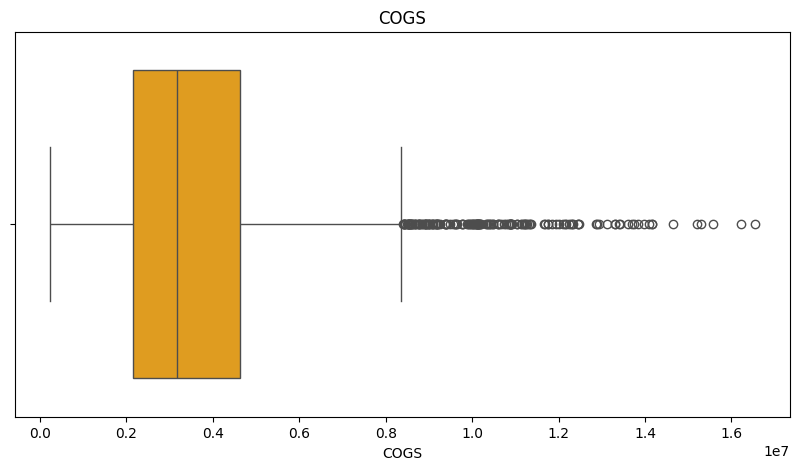

In [98]:
plt.figure(figsize=(10, 5))
sns.boxplot(x=sales['COGS'], color='orange')
plt.title("COGS")
plt.show()

In [99]:
Q1_cogs = sales['COGS'].quantile(0.25)
Q3_cogs = sales['COGS'].quantile(0.75)
IQR_cogs = Q3_cogs - Q1_cogs
upper_limit_cogs = Q3_cogs + 1.5 * IQR_cogs
lower_limit_cogs = Q1_cogs - 1.5 * IQR_cogs

cogs_outliers = sales[(sales['COGS'] > upper_limit_cogs) | (sales['COGS'] < lower_limit_cogs)]
print(f"Số lượng Outliers của COGS: {len(cogs_outliers)}")
display(cogs_outliers.sort_values(by='COGS', ascending=False).head(10))

Số lượng Outliers của COGS: 165


,Date,Revenue,COGS,is_holiday,log_Revenue,log_COGS
2156,2018-05-30,20905271.35,16535857.67,1,16.855512,16.621042
1730,2017-03-30,17516038.82,16224964.49,0,16.678628,16.602062
2157,2018-05-31,19289944.12,15561846.10,1,16.775095,16.560333
2158,2018-06-01,19245165.78,15287542.60,1,16.772771,16.542549
1731,2017-03-31,16556662.03,15209810.10,0,16.622299,16.537451
1732,2017-04-01,15808755.61,14645912.76,0,16.576075,16.499672
1821,2017-06-29,14575854.67,14163551.21,0,16.494877,16.466182
1794,2017-06-02,17528852.88,14154253.77,0,16.679359,16.465526
1793,2017-06-01,17639270.88,14102311.81,1,16.685638,16.461849
1394,2016-04-28,17388183.19,13978683.94,1,16.671301,16.453044


In [100]:
sales['log_Revenue'] = np.log1p(sales['Revenue'])
sales['log_COGS'] = np.log1p(sales['COGS'])

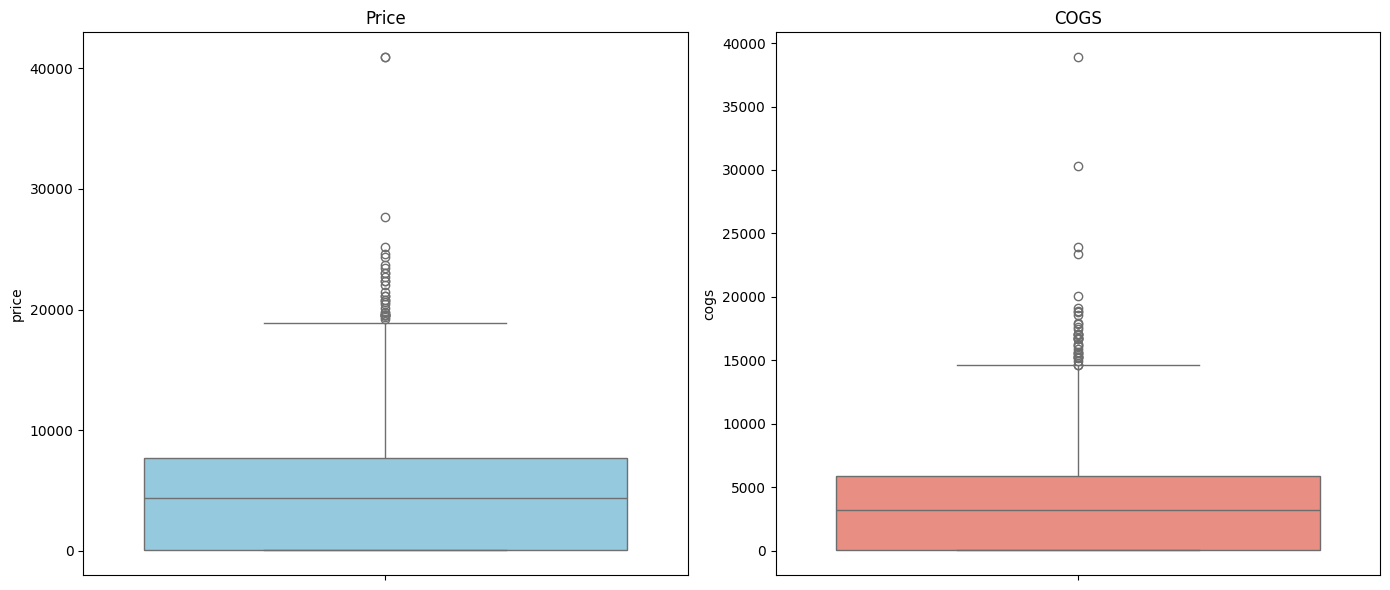

In [101]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(y=products['price'], ax=axes[0], color='skyblue')
axes[0].set_title('Price')

sns.boxplot(y=products['cogs'], ax=axes[1], color='salmon')
axes[1].set_title('COGS')

plt.tight_layout()
plt.show()

In [102]:
def get_outliers_by_group(df, group_col, value_col):
    outliers_list = []
    for group, group_data in df.groupby(group_col):
        Q1 = group_data[value_col].quantile(0.25)
        Q3 = group_data[value_col].quantile(0.75)
        IQR = Q3 - Q1
        upper = Q3 + 1.5 * IQR
        lower = Q1 - 1.5 * IQR
        
        outliers = group_data[(group_data[value_col] > upper) | (group_data[value_col] < lower)]
        outliers_list.append(outliers)
        
    return pd.concat(outliers_list)

price_outliers = get_outliers_by_group(products, 'segment', 'price')
print(f"Số lượng Outliers về giá (xét theo từng phân khúc): {len(price_outliers)}")

cogs_outliers = get_outliers_by_group(products, 'segment', 'cogs')
print(f"Số lượng Outliers về cogs (xét theo từng phân khúc): {len(cogs_outliers)}")

Số lượng Outliers về giá (xét theo từng phân khúc): 15
Số lượng Outliers về cogs (xét theo từng phân khúc): 14


In [103]:
display(price_outliers[['product_id', 'product_name', 'category', 'segment', 'price', 'cogs']].sort_values(by='price', ascending=False))
display(cogs_outliers[['product_id', 'product_name', 'category', 'segment', 'price', 'cogs']].sort_values(by='cogs', ascending=False))

,product_id,product_name,category,segment,price,cogs
674,309,LotusWear UE-30,Streetwear,Performance,40950.000000,30319.380000
712,347,LotusWear UE-68,Streetwear,Performance,40950.000000,38902.500000
661,296,LotusWear UE-17,Streetwear,Performance,27716.850000,14598.464895
699,334,LotusWear UE-55,Streetwear,Performance,25196.850000,23937.007500
863,507,SaigonFlex UM-12,Streetwear,Balanced,24574.291875,23345.577281
818,462,SaigonFlex UM-67,Streetwear,Balanced,24321.979756,20085.090883
718,353,LotusWear UE-74,Streetwear,Performance,20786.850000,15267.941325
1451,394,SaigonFlex RS-01,Outdoor,Premium,19686.870000,17464.222377
313,1902,BambooCraft UC-21,Streetwear,Everyday,19529.370000,16287.494580
427,519,SaigonFlex UE-07,Streetwear,Performance,19526.850000,9948.930075


,product_id,product_name,category,segment,price,cogs
712,347,LotusWear UE-68,Streetwear,Performance,40950.000000,38902.500000
674,309,LotusWear UE-30,Streetwear,Performance,40950.000000,30319.380000
699,334,LotusWear UE-55,Streetwear,Performance,25196.850000,23937.007500
863,507,SaigonFlex UM-12,Streetwear,Balanced,24574.291875,23345.577281
1451,394,SaigonFlex RS-01,Outdoor,Premium,19686.870000,17464.222377
552,1776,SaigonCore UE-11,Streetwear,Performance,17639.370000,16157.662920
718,353,LotusWear UE-74,Streetwear,Performance,20786.850000,15267.941325
661,296,LotusWear UE-17,Streetwear,Performance,27716.850000,14598.464895
556,1780,SaigonCore UE-15,Streetwear,Performance,17143.700000,14587.574330
1359,40,DragonWear MA-40,Casual,All-weather,12593.700000,11964.015000


In [104]:
price_outliers = price_outliers.copy() 
price_outliers['gross_margin'] = (price_outliers['price'] - price_outliers['cogs']) / price_outliers['price']
display(price_outliers[['product_id', 'segment', 'price', 'cogs', 'gross_margin']].sort_values(by='gross_margin'))

,product_id,segment,price,cogs,gross_margin
699,334,Performance,25196.850000,23937.007500,0.0500
863,507,Balanced,24574.291875,23345.577281,0.0500
712,347,Performance,40950.000000,38902.500000,0.0500
552,1776,Performance,17639.370000,16157.662920,0.0840
1451,394,Premium,19686.870000,17464.222377,0.1129
1462,806,Premium,13293.000000,11389.442400,0.1432
313,1902,Everyday,19529.370000,16287.494580,0.1660
818,462,Balanced,24321.979756,20085.090883,0.1742
674,309,Performance,40950.000000,30319.380000,0.2596
718,353,Performance,20786.850000,15267.941325,0.2655


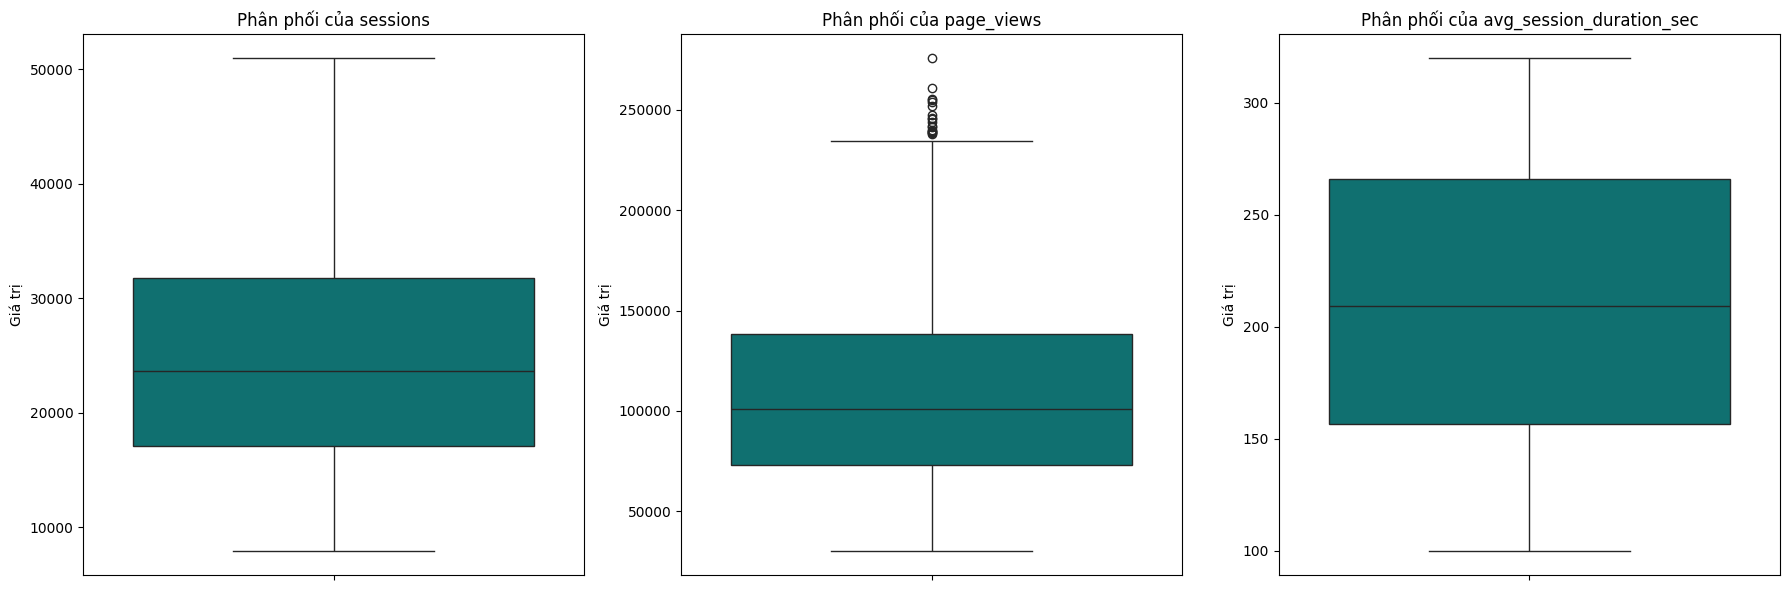

In [105]:
cols_to_check = ['sessions', 'page_views', 'avg_session_duration_sec']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for i, col in enumerate(cols_to_check):
    sns.boxplot(y=web_traffic[col], ax=axes[i], color='teal')
    axes[i].set_title(f'Phân phối của {col}')
    axes[i].set_ylabel('Giá trị')

plt.tight_layout()
plt.show()

In [106]:
outliers_dict = {} 

for col in cols_to_check:
    Q1 = web_traffic[col].quantile(0.25)
    Q3 = web_traffic[col].quantile(0.75)
    IQR = Q3 - Q1
    
    upper_limit = Q3 + 1.5 * IQR
    lower_limit = Q1 - 1.5 * IQR
    
    outliers = web_traffic[(web_traffic[col] > upper_limit) | (web_traffic[col] < lower_limit)]
    outliers_dict[col] = outliers
    
    print(f"Cột '{col}': Có {len(outliers)} điểm ngoại lai (Vượt ngưỡng {upper_limit:.2f})")

Cột 'sessions': Có 0 điểm ngoại lai (Vượt ngưỡng 53808.00)
Cột 'page_views': Có 18 điểm ngoại lai (Vượt ngưỡng 235742.00)
Cột 'avg_session_duration_sec': Có 0 điểm ngoại lai (Vượt ngưỡng 430.45)


In [107]:
display(outliers_dict['page_views'].sort_values(by='page_views', ascending=False).head(10))

,date,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,traffic_source
3425,2022-05-19,50386,38175,275560,0.00407,288.5,organic_search
3099,2021-06-27,49137,39354,260766,0.00541,308.4,social_media
3093,2021-06-21,50225,40208,255212,0.00545,177.1,paid_search
3036,2021-04-25,50274,40430,254833,0.00382,185.6,paid_search
3442,2022-06-05,47723,37307,253750,0.00398,206.4,organic_search
3399,2022-04-23,47534,35380,251668,0.00467,172.5,paid_search
2652,2020-04-06,48680,39248,247194,0.00334,136.5,organic_search
3086,2021-06-14,46537,36237,246126,0.00571,180.9,organic_search
2671,2020-04-25,45937,32490,245372,0.00576,137.1,referral
3395,2022-04-19,46622,34253,244067,0.00531,127.5,referral


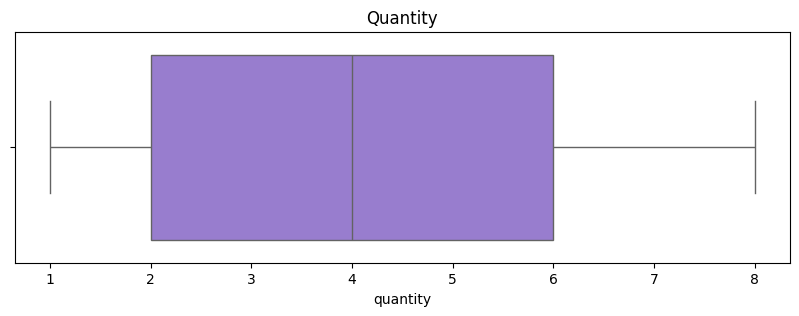

In [108]:
order_items = pd.read_csv("../data/processed/order_items.csv")
plt.figure(figsize=(10, 3))
sns.boxplot(x=order_items['quantity'], color='mediumpurple')
plt.title('Quantity')
plt.show()

In [109]:
order_items.to_csv('../data/processed/order_items.csv', index=False)
sales.to_csv("../data/processed/sales.csv", index=False)
web_traffic.to_csv("../data/processed/web_traffic.csv", index=False)
products.to_csv("../data/processed/products.csv", index=False)
orders.to_csv("../data/processed/orders.csv", index=False)
promotions.to_csv("../data/processed/promotions.csv", index=False)
inventory.to_csv("../data/processed/inventory.csv", index=False)
order_items.to_csv("../data/processed/order_items.csv", index=False)
returns.to_csv("../data/processed/returns.csv", index=False)
reviews.to_csv("../data/processed/reviews.csv", index=False)
sample_submission.to_csv("../data/processed/sample_submission.csv", index=False)
shipments.to_csv("../data/processed/shipments.csv", index=False)